In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import MeanAbsoluteError
from sklearn.metrics import mean_absolute_error

# Carga de datos

## Desde entorno local


In [ ]:
file_path = "Student_Performance.csv"

df = pd.read_csv(file_path, sep=",", engine="python")
df.head(5)

## Desde GitHub

In [2]:
REPO_NAME = "AA-II-RodriguezyBarros-Herrera-Zahradnicek"
BRANCH_NAME = "Problema_1"

if REPO_NAME not in os.getcwd():
  if not os.path.exists(REPO_NAME):
    !git clone -b {BRANCH_NAME} https://github.com/franciscoryb1/{REPO_NAME}.git
  os.chdir(REPO_NAME)

Cloning into 'AA-II-RodriguezyBarros-Herrera-Zahradnicek'...
remote: Enumerating objects: 24345, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 24345 (delta 3), reused 8 (delta 1), pack-reused 24330 (from 2)
Receiving objects: 100% (24345/24345), 410.72 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [3]:
file_path = "/content/AA-II-RodriguezyBarros-Herrera-Zahradnicek/Student_Performance.csv"

df = pd.read_csv(file_path, sep=",", engine="python")
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Características de entrada:

* Hours Studied: El número total de horas dedicadas al estudio por cada estudiante.

* Previous Scores: Las puntuaciones obtenidas por los estudiantes en exámenes previos.
* Extracurricular Activities: Si el estudiante participa en actividades extracurriculares (Sí o
No).
* Sleep Hours: El número promedio de horas de sueño que el estudiante tuvo por día.
* Sample Question Papers Practiced: El número de cuestionarios de muestra que el estudiante
practicó.
Además, el dataset incluye la variable objetivo:

### Variable de salida (target):

* Performance Index: Un índice que representa el rendimiento académico general de cada
estudiante, redondeado al entero más cercano. Este índice varía de 10 a 100, donde valores
más altos indican un mejor rendimiento.

# Split de datos

In [4]:
# Codificamos la unica variable categorica que tenemos, 'Extracurricular Activities'
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [5]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [6]:
# Dividimos el df original en train_val y test para luego obtener a partir de train_val los datasets de entrenamiento y validacion
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train, y_train, X_val y y_val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print(f"X_train: {len(X_train)} | y_train: {len(y_train)}")
print(f"X_val: {len(X_val)} | y_val: {len(y_val)}")
print(f"X_test: {len(X_test)} | y_test: {len(y_test)}")

X_train: 6400 | y_train: 6400
X_val: 1600 | y_val: 1600
X_test: 2000 | y_test: 2000


# Análisis exploratorio de datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [8]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


No tenemos valores faltantes en nuestro dataset.

In [9]:
df.describe(include='all')

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


## Matriz de correlacion

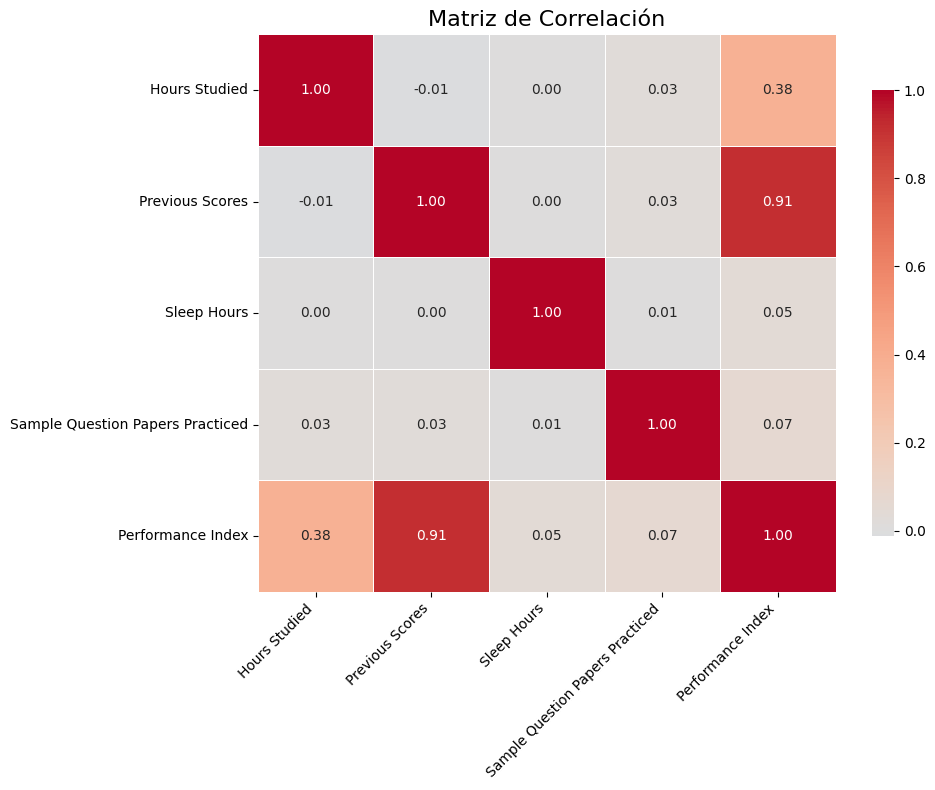

In [10]:
# Seleccionamos las columnas numericas para la matriz de correlación
numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                'Sample Question Papers Practiced', 'Performance Index']

X_train_correlation = X_train.assign(**{'Performance Index': y_train})

# Matriz de correlación
corr_matrix =X_train_correlation[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.title('Matriz de Correlación', fontsize=16)

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

No se aprecian fuertes correlaciones entre las variables numericas de nuestro dataset, la mas alta (0.91) entre 'Previous Scores' y 'Performance Index', lo que nos dice que en medida de que aumentan los puntajes de examentes anteriores, tambien aumenta el indice de rendimiento del alumno.

Otra correlacion que destaca, aunque con un valor mas bajo, es la de la variable Hours Studied y la variable target (0,38)

## Hours Studied

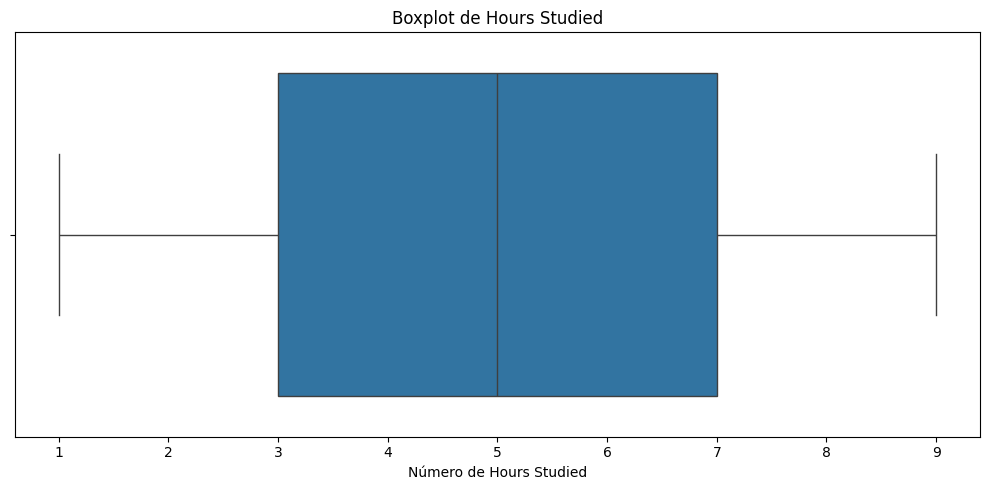

,Hours Studied
count,6400.000000
mean,4.973125
std,2.588800
min,1.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,9.000000


In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=X_train['Hours Studied'],
            flierprops=dict(marker='o', color='red', markersize=8))

plt.title('Boxplot de Hours Studied')
plt.xlabel('Número de Hours Studied')

plt.tight_layout()
plt.show()

X_train['Hours Studied'].describe()

La mayoría de los datos de la variable **Hours Studied** se encuentran entre 3 y 7 horas de estudio, con una mediana cerca de las 5 horas y no se observan valores atípicos.

## Previous Scores

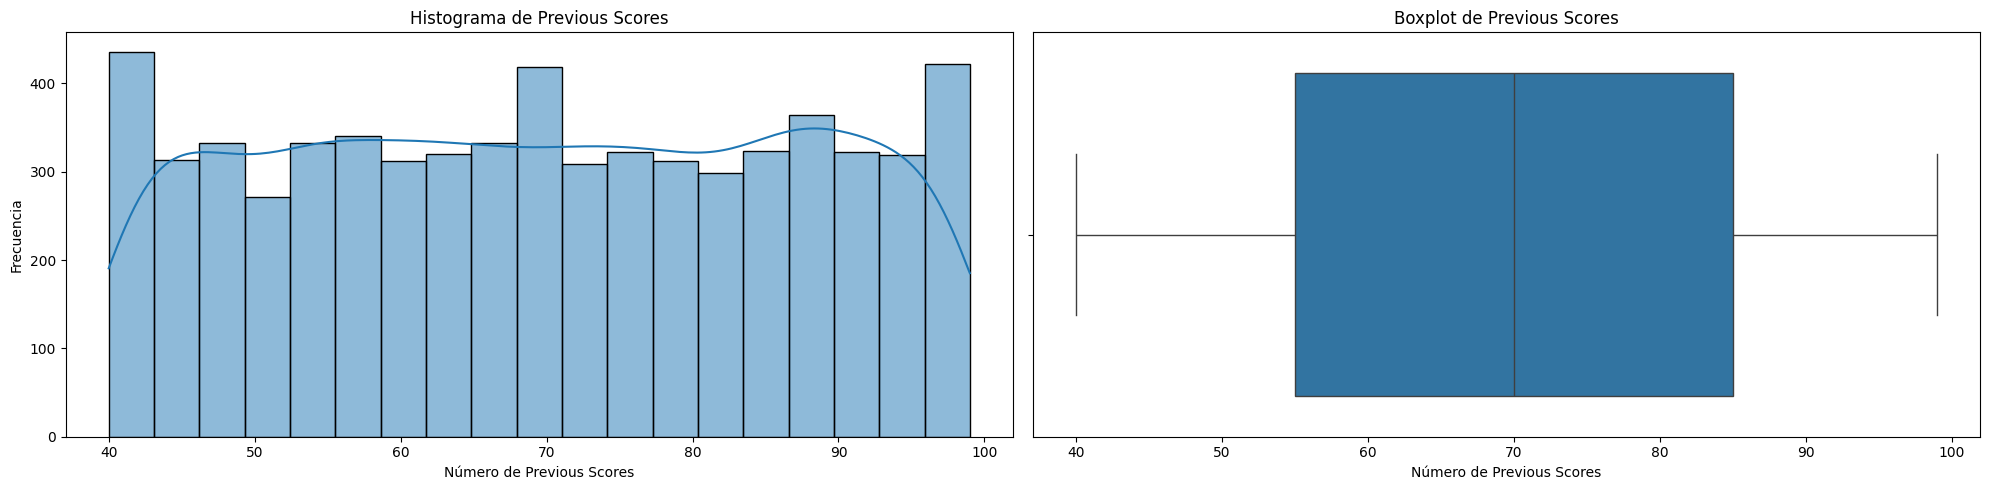

,Previous Scores
count,6400.000000
mean,69.574062
std,17.342594
min,40.000000
25%,55.000000
50%,70.000000
75%,85.000000
max,99.000000


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(X_train['Previous Scores'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Previous Scores')
axs[0].set_xlabel('Número de Previous Scores')
axs[0].set_ylabel('Frecuencia')

q1 = X_train['Previous Scores'].quantile(0.25)
q2 = X_train['Previous Scores'].quantile(0.5)
q3 = X_train['Previous Scores'].quantile(0.75)

# Boxplot
sns.boxplot(x=X_train['Previous Scores'], ax=axs[1])
axs[1].set_title('Boxplot de Previous Scores')
axs[1].set_xlabel('Número de Previous Scores')

plt.tight_layout()
plt.show()

X_train['Previous Scores'].describe()

En la variable **Previous Scores** la mayoría de los puntajes están entre 54 y 85, con una mediana cerca de 69, sin valores atípicos.

## Extracurricular Activities

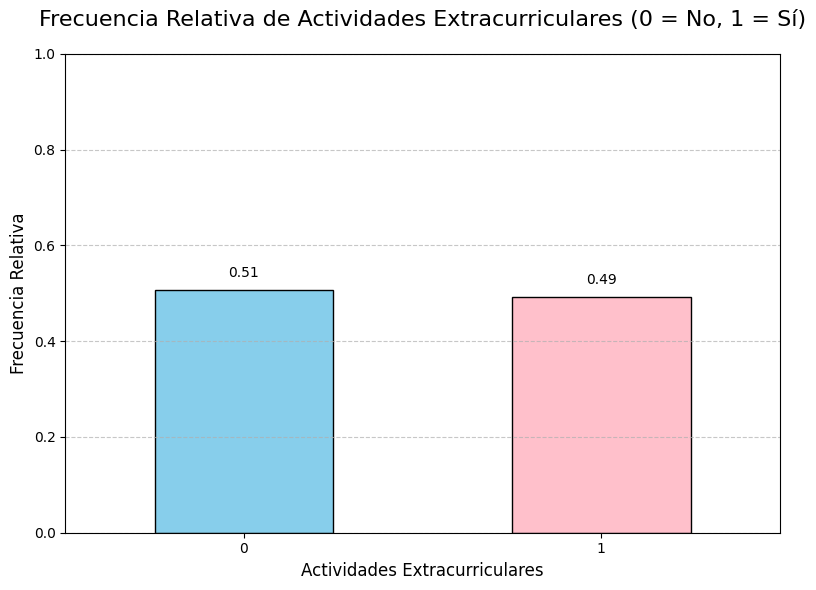

In [13]:
import matplotlib.pyplot as plt

rel_freq = X_train['Extracurricular Activities'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8, 6))
grafico = rel_freq.plot(
    kind='bar',
    color=['skyblue', 'pink'],
    edgecolor='black'
)

plt.title('Frecuencia Relativa de Actividades Extracurriculares (0 = No, 1 = Sí)', fontsize=16, pad=20)
plt.xlabel('Actividades Extracurriculares', fontsize=12)
plt.ylabel('Frecuencia Relativa', fontsize=12)
plt.ylim(0, 1)

for index, value in enumerate(rel_freq):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La variable "Extracurricular Activities" refrente si el alumno participa o no de actividades extracurriculares, siendo que no levemente por encima de si.

## Sleep Hours

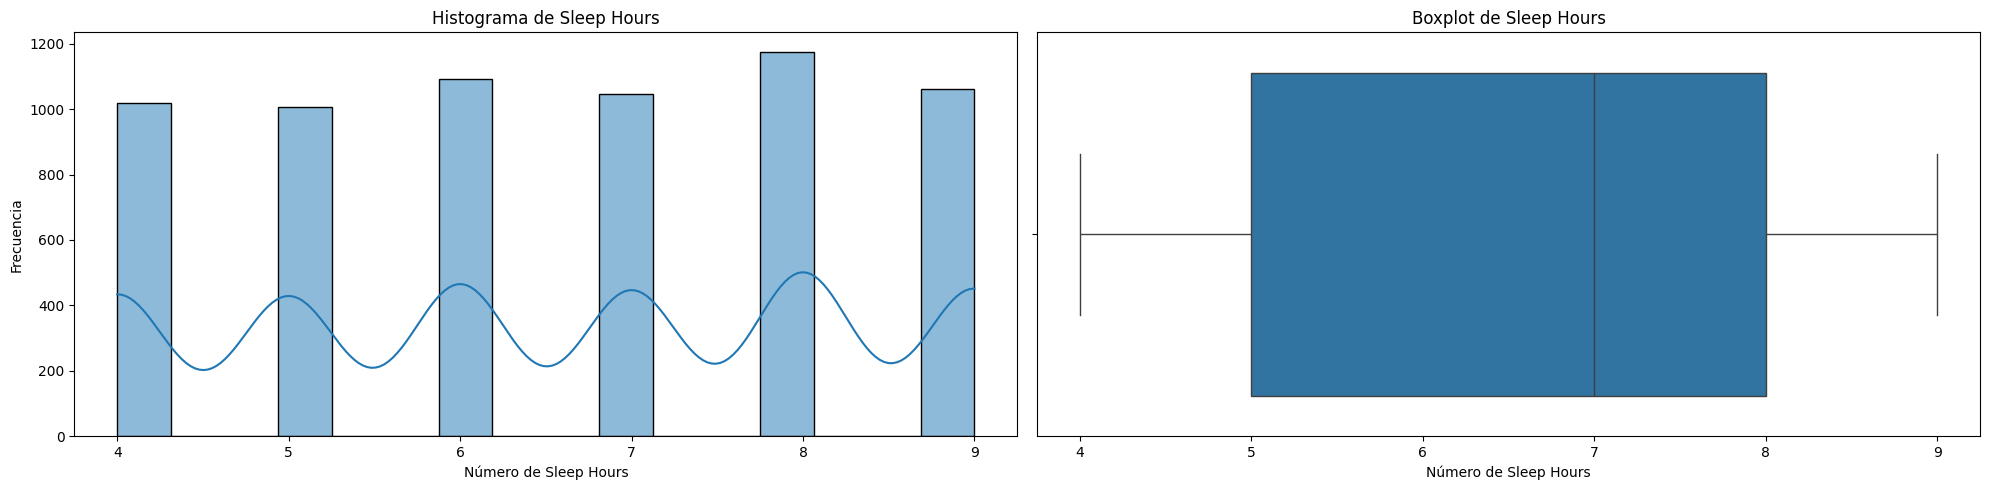

,Sleep Hours
count,6400.000000
mean,6.552656
std,1.697109
min,4.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,9.000000


In [14]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(X_train['Sleep Hours'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Sleep Hours')
axs[0].set_xlabel('Número de Sleep Hours')
axs[0].set_ylabel('Frecuencia')

q1 = X_train['Sleep Hours'].quantile(0.25)
q2 = X_train['Sleep Hours'].quantile(0.5)
q3 = X_train['Sleep Hours'].quantile(0.75)

# Boxplot
sns.boxplot(x=X_train['Sleep Hours'], ax=axs[1])
axs[1].set_title('Boxplot de Sleep Hours')
axs[1].set_xlabel('Número de Sleep Hours')

plt.tight_layout()
plt.show()

X_train['Sleep Hours'].describe()

El boxplot de Sleep Hours muestra que la mayoría de los datos están entre 5 y 8 horas de sueño, sin valores atípicos.

## Sample Question Papers Practiced

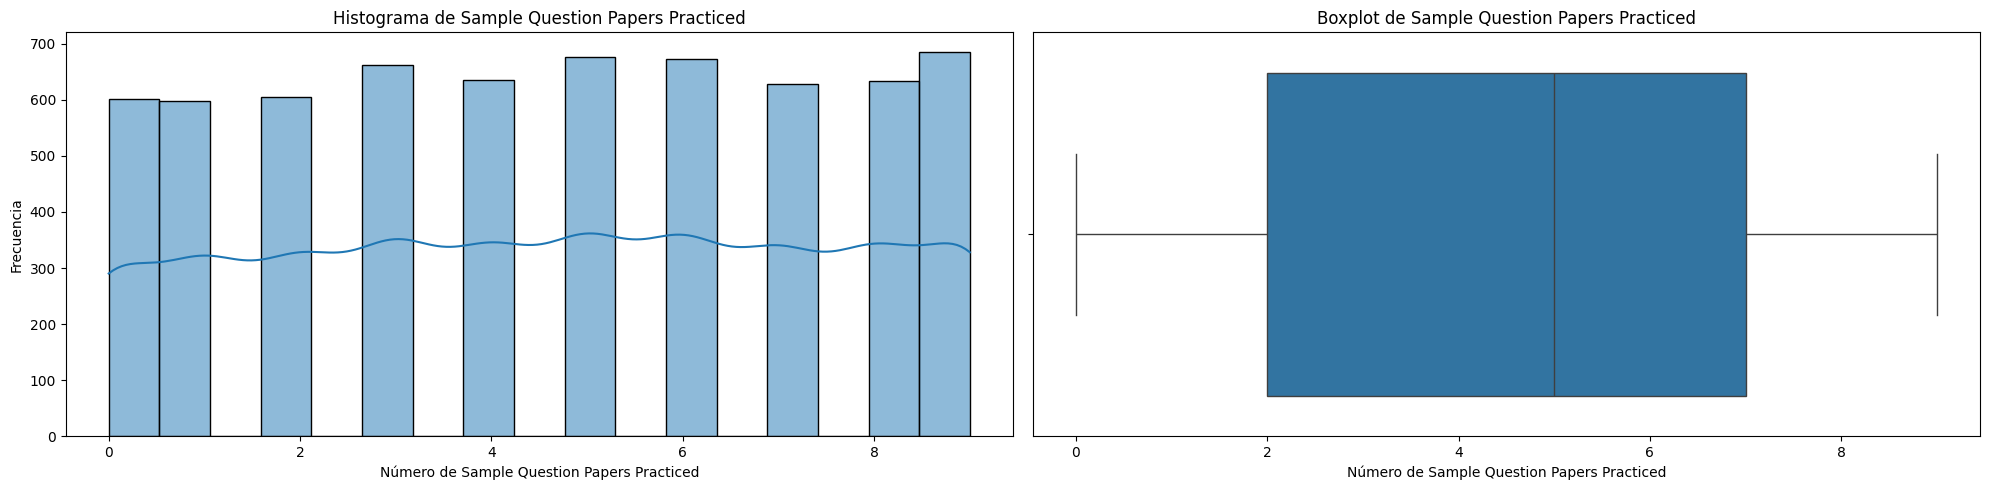

,Sample Question Papers Practiced
count,6400.000000
mean,4.593281
std,2.854888
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,9.000000


In [15]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(X_train['Sample Question Papers Practiced'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Sample Question Papers Practiced')
axs[0].set_xlabel('Número de Sample Question Papers Practiced')
axs[0].set_ylabel('Frecuencia')

q1 = X_train['Sample Question Papers Practiced'].quantile(0.25)
q2 = X_train['Sample Question Papers Practiced'].quantile(0.5)
q3 = X_train['Sample Question Papers Practiced'].quantile(0.75)

# Boxplot
sns.boxplot(x=X_train['Sample Question Papers Practiced'], ax=axs[1])
axs[1].set_title('Boxplot de Sample Question Papers Practiced')
axs[1].set_xlabel('Número de Sample Question Papers Practiced')

plt.tight_layout()
plt.show()

X_train['Sample Question Papers Practiced'].describe()

En la variable **Sample Question Papers Practiced** la mayoría de los datos están entre 2 y 7 cuestionarios practicados, con una mediana cerca de 5, sin valores atípicos.

# Escalado de datos

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Modelos

## Evaluacion de modelos

Dado a que nuestro problema no presenta outliers en ninguna variable y la variable categorica (Extracurricular Activities) esta practicamente balanceada, vamos a usar **MAE (Mean Absolute Error)** para evaluar nuestros modelos.

## Modelo base: Regresion lineal con las variables mas correlacionadas

In [17]:
scaler_rl = StandardScaler()
X_train_rl = scaler_rl.fit_transform(X_train[['Previous Scores', 'Hours Studied']])
X_val_rl = scaler_rl.transform(X_val[['Previous Scores', 'Hours Studied']])
X_test_rl = scaler_rl.transform(X_test[['Previous Scores', 'Hours Studied']])

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train_rl, y_train)
y_val_pred_linear_model = linear_model.predict(X_val_rl)
y_test_pred_linear_model = linear_model.predict(X_test_rl)

In [20]:
mae_train = mean_absolute_error(y_val, y_val_pred_linear_model)
mae_val = mean_absolute_error(y_val, y_val_pred_linear_model)
mae_test = mean_absolute_error(y_test, y_test_pred_linear_model)

print("MAE Validación:", mae_val)
print("MAE Test:", mae_test)
print(f"MAE% Val: {(mae_val / np.mean(y_val)) * 100:.2f}%")
print(f"MAE% Test: {(mae_test / np.mean(y_test)) * 100:.2f}%")

MAE Validación: 1.7637017639171788
MAE Test: 1.8271234329081505
MAE% Val: 3.19%
MAE% Test: 3.33%


## Redes Neuronales

In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
              loss='mean_absolute_error',
              metrics=[MeanAbsoluteError()])

early_stop = EarlyStopping(monitor='val_loss',
                           patience=20,
                           restore_best_weights=True,
                           min_delta=0.001)


# Callback para guardar el mejor modelo
checkpoint_cb = ModelCheckpoint(
    filepath='mejor_modelo.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop, checkpoint_cb],
    verbose=1
)

Epoch 1/150
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.9696 - mean_absolute_error: 15.9696
Epoch 1: val_loss improved from inf to 3.09428, saving model to mejor_modelo.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 15.8044 - mean_absolute_error: 15.8044 - val_loss: 3.0943 - val_mean_absolute_error: 3.0943
Epoch 2/150
 78/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0427 - mean_absolute_error: 3.0427
Epoch 2: val_loss improved from 3.09428 to 2.93588, saving model to mejor_modelo.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9738 - mean_absolute_error: 2.9738 - val_loss: 2.9359 - val_mean_absolute_error: 2.9359
Epoch 3/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5978 - mean_absolute_error: 2.5978
Epoch 3: val_loss did not improve from 2.93588
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5967 - mean_absolute_error: 2.5967 - val_loss: 3.2013 - val_mean_absolute_error: 3.2013
Epoch 4/150
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5108 

In [22]:
# Cargamos el mejor modelo guardado
mejor_modelo = tf.keras.models.load_model('mejor_modelo.keras')

train_loss, train_mae = mejor_modelo.evaluate(X_train_scaled, y_train, verbose=0)
val_loss, val_mae = mejor_modelo.evaluate(X_val_scaled, y_val, verbose=0)
test_loss, test_mae = mejor_modelo.evaluate(X_test_scaled, y_test, verbose=0)

print(f" - Train MAE: {train_mae:.4f}")
print(f" - Val MAE:   {val_mae:.4f}")
print(f" - Test MAE:  {test_mae:.4f}")

 - Train MAE: 1.6434
 - Val MAE:   1.6179
 - Test MAE:  1.6365


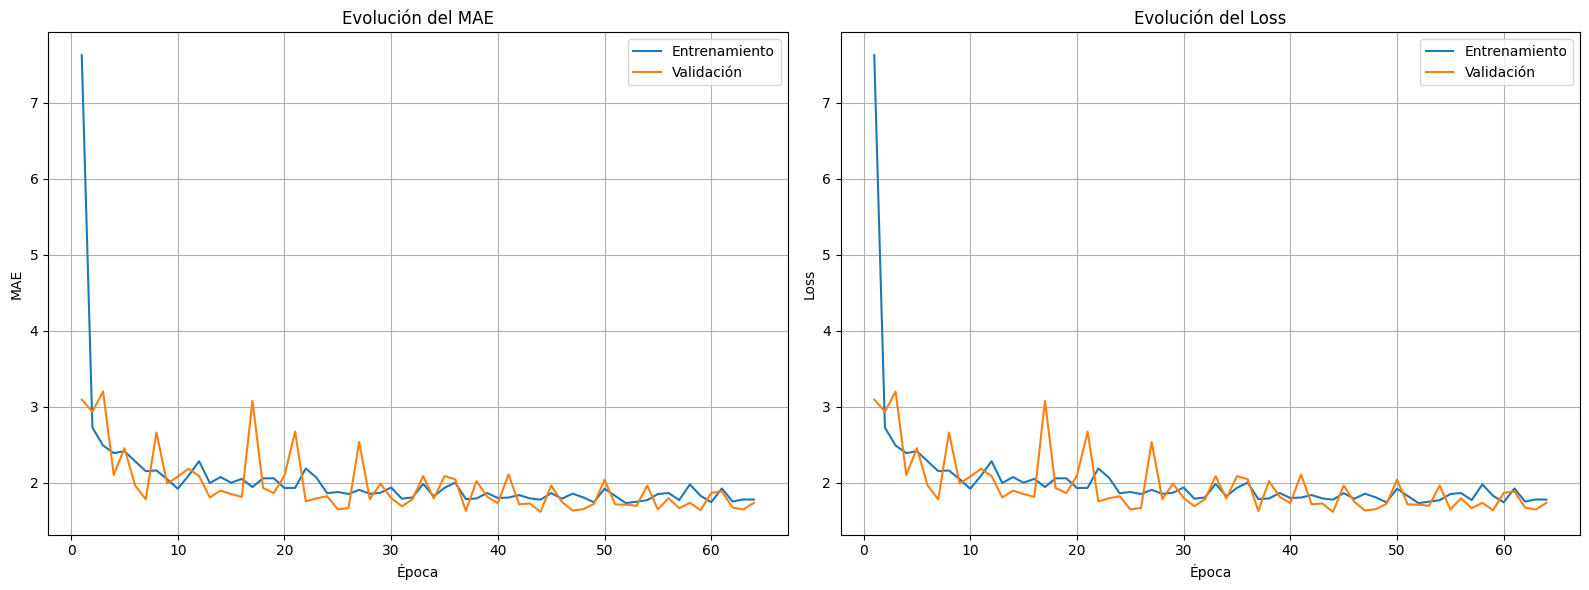

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# Gráfico 1: Evolución del MAE
plt.subplot(1, 2, 1)
sns.lineplot(data=history.history,
             x=range(1, len(history.history['mean_absolute_error']) + 1),
             y='mean_absolute_error',
             label='Entrenamiento')
sns.lineplot(data=history.history,
             x=range(1, len(history.history['val_mean_absolute_error']) + 1),
             y='val_mean_absolute_error',
             label='Validación')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('Evolución del MAE')
plt.legend()
plt.grid(True)

# Gráfico 2: Evolución del Loss
plt.subplot(1, 2, 2)
sns.lineplot(data=history.history,
             x=range(1, len(history.history['loss']) + 1),
             y='loss',
             label='Entrenamiento')
sns.lineplot(data=history.history,
             x=range(1, len(history.history['val_loss']) + 1),
             y='val_loss',
             label='Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Evolución del Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Resultados

## Regresión lineal

* Val MAE: 1.76
* Test MAE: 1.83

* Val MAE %: 3.19%
* Test MAE %: 3.33%

## NN

* Train MAE: 1.6682

* Validation MAE: 1.6418

* Test MAE: 1.6564

## Conclusión

Ambos modelos obtuvieron resultados cercanos, aunque la red neuronal logro un mejor desempeño en validación y test.

En este caso consideramos que es importante considerar las diferencias entre ambos modelos implementados, tanto en su estructura como en la cantidad de informacion que utilizaron, el modelo de **Regresion lineal** se entreno unicamente con las dos variables que observamos mas correlacionadas linealmente (Previous Scores y Hours Studied) a la variable target (Performance Index) mientras que el modelo de **Red neuronal** trabajó con todas las variables disponibles y además tiene una arquitectura de múltiples capas y neuronas que le permite capturar patrones no lineales y relaciones más complejas entre los datos.


Concluimos que a pesar de su simplicidad, la regresión lineal logro un rendimiento muy cercano al de la red neuronal. Considerando que utilizó solo dos variables y una estructura muy simple, sus resultados son más que aceptables y dependiendo de los objetivos del proyecto, este modelo podría ser más que suficiente, sin necesidad de recurrir a modelos mas complejos como una red neuronal.